In [17]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define dataset paths in Google Drive
dataset_path = "/content/drive/MyDrive/DS"  # Change to your actual path
normal_path = os.path.join(dataset_path, "normal")
stroke_path = os.path.join(dataset_path, "stroke")

# Read and preprocess images
data = []
labels = []

def load_images(folder_path, label):
    images = []
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        try:
            image = Image.open(img_path).resize((224, 224)).convert('RGB')
            data.append(np.array(image, dtype=np.float32) / 255.0)  # Normalize and append
            labels.append(label)
        except Exception as e:
            print(f"Error loading {img_file}: {e}")

# Load images from both classes
load_images(normal_path, 0)  # Normal class (label = 0)
load_images(stroke_path, 1)  # Stroke class (label = 1)

# Convert lists to NumPy arrays
x = np.array(data)
y = np.array(labels)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True, random_state=42)
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (1299, 224, 224, 3) Test shape: (325, 224, 224, 3)


In [18]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU

cnn_model = Sequential([
    Conv2D(32, kernel_size=(3,3), strides=1, padding="valid", activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=2),
    Conv2D(64, kernel_size=(3,3), strides=1, padding="valid", activation="relu"),
    MaxPooling2D(pool_size=2),
    Conv2D(128, kernel_size=(3,3), strides=1, padding="valid", activation="relu"),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])
cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
print("CNN Model Summary:")
cnn_model.summary()
cnn_history = cnn_model.fit(x_train, y_train, batch_size=32, epochs=20)

CNN Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,277,697 (84.98 MB)

 Trainable params: 22,277,697 (84.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.5699 - loss: 0.7822
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7879 - loss: 0.4994
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9331 - loss: 0.1861
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9488 - loss: 0.1297
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9671 - loss: 0.0851
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9846 - loss: 0.0394
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9548 - loss: 0.1207
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9920 - loss: 0.0239
Epoch 9/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9943 - loss: 0.0146
Epoch 10/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9870 - loss: 0.0381
Epoch 11/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9887 - loss: 0.0405
Epoch 12/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accurac

In [20]:
# Evaluate CNN model
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test, verbose=1)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9615 - loss: 0.3766
CNN Test Accuracy: 0.9723


In [21]:
from sklearn.metrics import classification_report, accuracy_score
cnn_preds = cnn_model.predict(x_test)
cnn_preds_binary = (cnn_preds > 0.5).astype(int)
print("CNN Model Performance:")
print(classification_report(y_test, cnn_preds_binary))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
CNN Model Performance:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       188
           1       0.96      0.97      0.97       137

    accuracy                           0.97       325
   macro avg       0.97      0.97      0.97       325
weighted avg       0.97      0.97      0.97       325



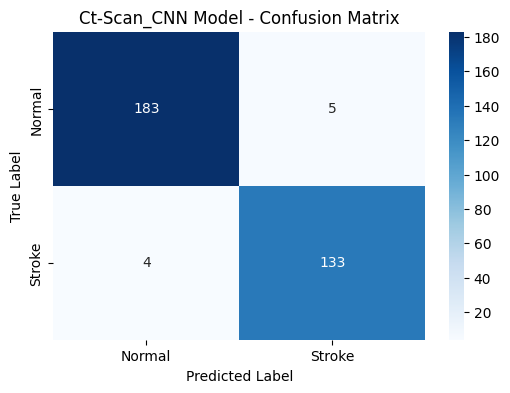

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cnn_cm = confusion_matrix(y_test, cnn_preds_binary)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cnn_cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Normal', 'Stroke'], yticklabels=['Normal', 'Stroke'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ct-Scan_CNN Model - Confusion Matrix")
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


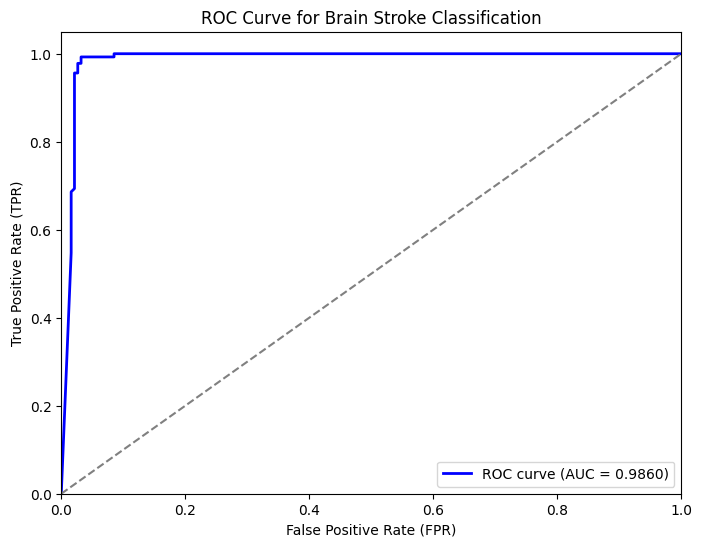

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Get prediction probabilities for the stroke class (NOT binary labels)
y_pred_probs = cnn_model.predict(x_test)  # Probabilities for class 1 (Stroke)

# Step 2: Compute the ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)  # FPR, TPR
roc_auc = auc(fpr, tpr)  # Compute AUC score

# Step 3: Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Brain Stroke Classification")
plt.legend(loc="lower right")
plt.show()



In [24]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
import kagglehub

# Download the dataset
dataset_path = kagglehub.dataset_download("afridirahman/brain-stroke-ct-image-dataset")

# Construct correct paths
normal_path = os.path.join(dataset_path, "Brain_Data_Organised", "Normal")
stroke_path = os.path.join(dataset_path, "Brain_Data_Organised", "Stroke")

# List files
normal_folder = os.listdir(normal_path)
stroke_folder = os.listdir(stroke_path)

# Read and preprocess images
data = []
labels = []

def load_images(folder_path, label):
    images = []
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        try:
            image = Image.open(img_path).resize((224, 224)).convert('RGB')
            images.append(np.array(image, dtype=np.float32))  # Convert to float
            labels.append(label)
        except Exception as e:
            print(f"Error loading {img_file}: {e}")
    return images

data.extend(load_images(normal_path, 0))  # Normal class (label = 0)
data.extend(load_images(stroke_path, 1))  # Stroke class (label = 1)

# Convert lists to NumPy arrays
x = np.array(data) / 255.0  # Normalize
y = np.array(labels)

# Train-test split
#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True, random_state=42)
#print("Train shape:", x_train.shape, "Test shape:", x_test.shape)




In [25]:
# Evaluate CNN model
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x, y, verbose=1)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3771 - loss: 16.9503
CNN Test Accuracy: 0.4802


In [26]:
from sklearn.metrics import classification_report, accuracy_score
cnn_preds = cnn_model.predict(x)
cnn_preds_binary = (cnn_preds > 0.5).astype(int)
print("CNN Model Performance:")
print(classification_report(y, cnn_preds_binary))

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
CNN Model Performance:
              precision    recall  f1-score   support

           0       0.65      0.34      0.45      1551
           1       0.40      0.70      0.51       950

    accuracy                           0.48      2501
   macro avg       0.52      0.52      0.48      2501
weighted avg       0.56      0.48      0.47      2501



In [27]:
import pickle

# Save model architecture and weights separately
model_json = cnn_model.to_json()  # Convert model architecture to JSON
model_weights = cnn_model.get_weights()  # Extract weights

# Save architecture and weights in a pickle file
with open("cnn_MRI_brain_stroke_model.pkl", "wb") as f:
    pickle.dump({"architecture": model_json, "weights": model_weights}, f)

print("Model saved successfully in .pkl format!")


Model saved successfully in .pkl format!


In [28]:
from google.colab import files
files.download("cnn_MRI_brain_stroke_model.pkl")  # This will download the file to your local system


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>